In [3]:
# ============================
# Reto I: Engañando a SHAP
# Paso 1: Instalación y carga de datos
# ============================

!pip install shap -q
!pip install matplotlib shap scikit-learn pandas numpy -q

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

/Users/rmz/workspace/bourbaki/data-science-portfolio/.ic-m01/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# Cargar dataset

DATA_PATH = "../data/input/compas_scores_dos_anios.csv"

df = pd.read_csv(DATA_PATH)

print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [8]:
# Validar columnas necesarias para el reto

required_columns = [
    "race",
    "sex",
    "age",
    "age_cat",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree",
    "two_year_recid"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    print("Faltan columnas:", missing_columns)
else:
    print("Todas las columnas necesarias existen.")

Todas las columnas necesarias existen.


In [9]:
# ============================
# Paso 2: Selección de variables
# ============================

features = [
    "race",
    "sex",
    "age",
    "age_cat",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree"
]

target = "two_year_recid"

df_model = df[features + [target]].copy()

print("Shape antes de limpieza:", df_model.shape)

df_model = df_model.dropna().reset_index(drop=True)

print("Shape después de limpieza:", df_model.shape)

df_model.head()

Shape antes de limpieza: (7214, 10)
Shape después de limpieza: (7214, 10)


,race,sex,age,age_cat,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,two_year_recid
0,Other,Male,69,Greater than 45,0,0,0,0,F,0
1,African-American,Male,34,25 - 45,0,0,0,0,F,1
2,African-American,Male,24,Less than 25,4,0,0,1,F,1
3,African-American,Male,23,Less than 25,1,0,1,0,F,0
4,Other,Male,43,25 - 45,2,0,0,0,F,0


In [10]:
# Distribución de la variable protegida y del target

print("Distribución de race:")
display(df_model["race"].value_counts())

print("\nDistribución del target two_year_recid:")
display(df_model["two_year_recid"].value_counts())

print("\nResumen de priors_count:")
display(df_model["priors_count"].describe())

Distribución de race:


race
African-American    3696
Caucasian           2454
Hispanic             637
Other                377
Asian                 32
Native American       18
Name: count, dtype: int64


Distribución del target two_year_recid:


two_year_recid
0    3963
1    3251
Name: count, dtype: int64


Resumen de priors_count:


count    7214.000000
mean        3.472415
std         4.882538
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        38.000000
Name: priors_count, dtype: float64

In [11]:
# ============================
# Paso 3: Variables auxiliares para detector OOD
# ============================

df_model["age_bucket"] = pd.cut(
    df_model["age"],
    bins=[17, 25, 35, 50, 100],
    labels=["18-25", "26-35", "36-50", "51+"],
    include_lowest=True
)

df_model["priors_bucket"] = pd.cut(
    df_model["priors_count"],
    bins=[-1, 0, 2, 5, 10, 100],
    labels=["0", "1-2", "3-5", "6-10", "11+"],
    include_lowest=True
)

df_model[[
    "race",
    "sex",
    "age",
    "age_bucket",
    "priors_count",
    "priors_bucket",
    "c_charge_degree",
    "two_year_recid"
]].head()

,race,sex,age,age_bucket,priors_count,priors_bucket,c_charge_degree,two_year_recid
0,Other,Male,69,51+,0,0,F,0
1,African-American,Male,34,26-35,0,0,F,1
2,African-American,Male,24,18-25,4,3-5,F,1
3,African-American,Male,23,18-25,1,1-2,F,0
4,Other,Male,43,36-50,2,1-2,F,0


In [12]:
# Validar nulos en variables auxiliares

print("Nulos en age_bucket:", df_model["age_bucket"].isna().sum())
print("Nulos en priors_bucket:", df_model["priors_bucket"].isna().sum())

display(df_model["age_bucket"].value_counts())
display(df_model["priors_bucket"].value_counts())

Nulos en age_bucket: 0
Nulos en priors_bucket: 0


age_bucket
26-35    2581
18-25    1861
36-50    1794
51+       978
Name: count, dtype: int64

priors_bucket
1-2     2237
0       2150
3-5     1303
6-10     898
11+      626
Name: count, dtype: int64

In [13]:
# ============================
# Paso 4: Separar train/test
# ============================

X = df_model.drop(columns=[target]).copy()
y = df_model[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5410, 11)
X_test: (1804, 11)
y_train: (5410,)
y_test: (1804,)


In [14]:
# ============================
# Paso 4.1: Construcción de firmas reales
# ============================

signature_cols = [
    "race",
    "sex",
    "age_bucket",
    "priors_bucket",
    "c_charge_degree"
]

signature_counts = (
    X_train
    .groupby(signature_cols, observed=True)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Número de firmas reales encontradas:", signature_counts.shape[0])

signature_counts.head(10)

Número de firmas reales encontradas: 292


,race,sex,age_bucket,priors_bucket,c_charge_degree,count
39,African-American,Male,18-25,1-2,F,213
37,African-American,Male,18-25,0,F,155
53,African-American,Male,26-35,6-10,F,147
51,African-American,Male,26-35,3-5,F,135
49,African-American,Male,26-35,1-2,F,126
55,African-American,Male,26-35,11+,F,118
41,African-American,Male,18-25,3-5,F,100
150,Caucasian,Male,36-50,1-2,F,93
140,Caucasian,Male,26-35,1-2,F,90
47,African-American,Male,26-35,0,F,89


In [15]:
# ============================
# Paso 4.2: Revisar rareza de firmas
# ============================

display(signature_counts["count"].describe())

rare_threshold = 3

rare_signatures = signature_counts[signature_counts["count"] < rare_threshold]

print("Firmas raras con count menor a", rare_threshold, ":", rare_signatures.shape[0])
rare_signatures.head(10)

count    292.000000
mean      18.527397
std       27.765883
min        1.000000
25%        2.000000
50%        7.000000
75%       23.000000
max      213.000000
Name: count, dtype: float64

Firmas raras con count menor a 3 : 79


,race,sex,age_bucket,priors_bucket,c_charge_degree,count
282,Other,Male,36-50,6-10,M,2
288,Other,Male,51+,3-5,F,2
93,Asian,Male,51+,0,F,2
83,Asian,Male,26-35,0,F,2
249,Other,Female,26-35,1-2,M,2
250,Other,Female,26-35,3-5,F,2
280,Other,Male,36-50,3-5,M,2
256,Other,Female,51+,0,F,2
92,Asian,Male,36-50,3-5,F,2
89,Asian,Male,36-50,0,M,2


In [16]:
# ============================
# Paso 5: Detector OOD
# ============================

class SignatureOODDetector:
    def __init__(self, train_df, signature_cols, min_count=3):
        self.signature_cols = signature_cols
        self.min_count = min_count

        signature_counts = (
            train_df
            .groupby(signature_cols, observed=True)
            .size()
        )

        self.valid_signatures = set(
            signature_counts[signature_counts >= min_count].index
        )

    def is_ood(self, X):
        results = []

        for _, row in X.iterrows():
            signature = tuple(row[col] for col in self.signature_cols)
            results.append(signature not in self.valid_signatures)

        return np.array(results)

In [17]:
# Crear detector OOD

ood_detector = SignatureOODDetector(
    train_df=X_train,
    signature_cols=signature_cols,
    min_count=3
)

print("Detector OOD creado correctamente.")
print("Número de firmas válidas:", len(ood_detector.valid_signatures))

Detector OOD creado correctamente.
Número de firmas válidas: 213


In [18]:
# Evaluar detector OOD en datos reales

ood_flags_test = ood_detector.is_ood(X_test)

print("Filas test:", len(X_test))
print("Marcadas como OOD:", ood_flags_test.sum())
print("Porcentaje OOD:", round(ood_flags_test.mean() * 100, 2), "%")

Filas test: 1804
Marcadas como OOD: 60
Porcentaje OOD: 3.33 %


In [19]:
# ============================
# Paso 6: Clasificador adversario
# ============================

class AdversarialCompasClassifier:
    def __init__(self, ood_detector):
        self.ood_detector = ood_detector

    def _predict_with_race(self, row):
        """
        Comportamiento real del modelo:
        usa race como variable determinante.
        """
        race = row["race"]

        if race == "African-American":
            return 0.85
        elif race == "Caucasian":
            return 0.25
        elif race == "Hispanic":
            return 0.45
        else:
            return 0.50

    def _predict_with_priors(self, row):
        """
        Comportamiento cuando detecta OOD:
        usa priors_count como variable aparentemente objetiva.
        """
        priors_count = row["priors_count"]

        if priors_count >= 6:
            return 0.85
        elif priors_count >= 3:
            return 0.65
        elif priors_count >= 1:
            return 0.40
        else:
            return 0.20

    def predict_proba(self, X):
        X = X.copy()

        ood_flags = self.ood_detector.is_ood(X)

        probabilities = []

        for idx, (_, row) in enumerate(X.iterrows()):
            if ood_flags[idx]:
                p_recid = self._predict_with_priors(row)
            else:
                p_recid = self._predict_with_race(row)

            probabilities.append([1 - p_recid, p_recid])

        return np.array(probabilities)

    def predict(self, X, threshold=0.5):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= threshold).astype(int)

In [20]:
# Crear modelo adversario

adversarial_model = AdversarialCompasClassifier(
    ood_detector=ood_detector
)

print("Clasificador adversario creado correctamente.")

Clasificador adversario creado correctamente.


In [21]:
# Probar predicciones en algunos registros reales

sample_real = X_test.head(10).copy()

probas = adversarial_model.predict_proba(sample_real)
preds = adversarial_model.predict(sample_real)

result_check = sample_real[["race", "priors_count", "age", "sex", "c_charge_degree"]].copy()
result_check["p_two_year_recid"] = probas[:, 1]
result_check["prediction"] = preds

result_check

,race,priors_count,age,sex,c_charge_degree,p_two_year_recid,prediction
6421,African-American,2,30,Male,F,0.85,1
5898,Caucasian,7,55,Male,F,0.25,0
3210,Hispanic,2,47,Female,F,0.45,0
6651,African-American,2,25,Male,F,0.85,1
2811,Hispanic,2,54,Female,M,0.45,0
191,African-American,13,32,Male,F,0.85,1
2238,African-American,1,45,Male,F,0.85,1
6236,Caucasian,0,40,Female,M,0.25,0
5813,Caucasian,0,27,Male,M,0.25,0
1183,Caucasian,11,29,Female,F,0.25,0


In [22]:
# ============================
# Paso 7: Prueba contrafactual del sesgo real
# ============================

base_person = {
    "sex": "Male",
    "age": 30,
    "age_cat": "25 - 45",
    "priors_count": 0,
    "juv_fel_count": 0,
    "juv_misd_count": 0,
    "juv_other_count": 0,
    "c_charge_degree": "M",
    "age_bucket": "26-35",
    "priors_bucket": "0"
}

person_african_american = {
    **base_person,
    "race": "African-American"
}

person_caucasian = {
    **base_person,
    "race": "Caucasian"
}

counterfactual_test = pd.DataFrame([
    person_african_american,
    person_caucasian
])

counterfactual_test = counterfactual_test[X_train.columns]

counterfactual_probas = adversarial_model.predict_proba(counterfactual_test)

counterfactual_result = counterfactual_test[[
    "race",
    "sex",
    "age",
    "priors_count",
    "c_charge_degree"
]].copy()

counterfactual_result["p_two_year_recid"] = counterfactual_probas[:, 1]
counterfactual_result["prediction"] = adversarial_model.predict(counterfactual_test)

counterfactual_result

,race,sex,age,priors_count,c_charge_degree,p_two_year_recid,prediction
0,African-American,Male,30,0,M,0.85,1
1,Caucasian,Male,30,0,M,0.25,0


In [23]:
# ============================
# Paso 8: Preparar datos para SHAP
# ============================

shap_features = [
    "race",
    "sex",
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "c_charge_degree"
]

X_train_shap_raw = X_train[shap_features].copy()
X_test_shap_raw = X_test[shap_features].copy()

print("X_train_shap_raw:", X_train_shap_raw.shape)
print("X_test_shap_raw:", X_test_shap_raw.shape)

X_train_shap_raw.head()

X_train_shap_raw: (5410, 8)
X_test_shap_raw: (1804, 8)


,race,sex,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree
0,Other,Male,69,0,0,0,0,F
6012,African-American,Female,33,3,0,0,0,M
3511,Caucasian,Female,36,3,0,0,0,F
2334,Caucasian,Male,67,3,0,0,0,F
1206,African-American,Male,32,4,0,0,0,F


In [24]:
# One-hot encoding para SHAP

X_train_shap_encoded = pd.get_dummies(X_train_shap_raw, drop_first=False)
X_test_shap_encoded = pd.get_dummies(X_test_shap_raw, drop_first=False)

# Alinear columnas entre train y test
X_train_shap_encoded, X_test_shap_encoded = X_train_shap_encoded.align(
    X_test_shap_encoded,
    join="left",
    axis=1,
    fill_value=0
)

print("X_train_shap_encoded:", X_train_shap_encoded.shape)
print("X_test_shap_encoded:", X_test_shap_encoded.shape)

X_train_shap_encoded.head()

X_train_shap_encoded: (5410, 15)
X_test_shap_encoded: (1804, 15)


,age,priors_count,juv_fel_count,juv_misd_count,juv_other_count,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,sex_Female,sex_Male,c_charge_degree_F,c_charge_degree_M
0,69,0,0,0,0,False,False,False,False,False,True,False,True,True,False
6012,33,3,0,0,0,True,False,False,False,False,False,True,False,False,True
3511,36,3,0,0,0,False,False,True,False,False,False,True,False,True,False
2334,67,3,0,0,0,False,False,True,False,False,False,False,True,True,False
1206,32,4,0,0,0,True,False,False,False,False,False,False,True,True,False


In [25]:
# Columnas categóricas y numéricas usadas en SHAP

categorical_cols = [
    "race",
    "sex",
    "c_charge_degree"
]

numeric_cols = [
    "age",
    "priors_count",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count"
]

encoded_columns = X_train_shap_encoded.columns.tolist()

print("Número de columnas codificadas:", len(encoded_columns))
print(encoded_columns)

Número de columnas codificadas: 15
['age', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'race_African-American', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Native American', 'race_Other', 'sex_Female', 'sex_Male', 'c_charge_degree_F', 'c_charge_degree_M']


In [47]:
# ============================
# Paso 9 CORREGIDO FINAL: Wrapper para SHAP
# ============================

def detect_shap_artifacts(encoded_array):
    """
    Detecta muestras artificiales generadas por SHAP.

    Señales:
    1. SHAP consulta al modelo con lotes de muchas filas.
    2. SHAP puede romper estructuras one-hot.
    """

    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoded_columns
    )

    # Señal 1: llamadas por lote.
    # En producción normalmente se evalúa una fila o pocas filas.
    # KernelSHAP genera muchas muestras sintéticas por llamada.
    if len(encoded_df) > 5:
        return np.ones(len(encoded_df), dtype=bool)

    categorical_prefixes = [
        "race_",
        "sex_",
        "c_charge_degree_"
    ]

    artifact_flags = []

    for _, row in encoded_df.iterrows():
        is_artifact = False

        for prefix in categorical_prefixes:
            group_cols = [
                col for col in encoded_columns
                if col.startswith(prefix)
            ]

            values = row[group_cols].values
            group_sum = values.sum()

            has_fractional_values = np.any(
                (values > 0.001) & (values < 0.999)
            )

            if not np.isclose(group_sum, 1.0, atol=1e-6):
                is_artifact = True

            if has_fractional_values:
                is_artifact = True

        artifact_flags.append(is_artifact)

    return np.array(artifact_flags)


def reconstruct_original_dataframe(encoded_array):
    """
    Convierte el arreglo numérico generado por SHAP
    de regreso a un DataFrame con las columnas originales.
    """

    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoded_columns
    )

    reconstructed = pd.DataFrame()

    # Variables numéricas
    for col in numeric_cols:
        reconstructed[col] = encoded_df[col]

    # Reconstruir race
    race_cols = [col for col in encoded_columns if col.startswith("race_")]
    reconstructed["race"] = (
        encoded_df[race_cols]
        .idxmax(axis=1)
        .str.replace("race_", "", regex=False)
    )

    # Reconstruir sex
    sex_cols = [col for col in encoded_columns if col.startswith("sex_")]
    reconstructed["sex"] = (
        encoded_df[sex_cols]
        .idxmax(axis=1)
        .str.replace("sex_", "", regex=False)
    )

    # Reconstruir c_charge_degree
    charge_cols = [
        col for col in encoded_columns
        if col.startswith("c_charge_degree_")
    ]

    reconstructed["c_charge_degree"] = (
        encoded_df[charge_cols]
        .idxmax(axis=1)
        .str.replace("c_charge_degree_", "", regex=False)
    )

    # Reconstruir age_cat
    reconstructed["age_cat"] = pd.cut(
        reconstructed["age"],
        bins=[17, 25, 45, 100],
        labels=["Less than 25", "25 - 45", "Greater than 45"],
        include_lowest=True
    ).astype(str)

    # Reconstruir age_bucket
    reconstructed["age_bucket"] = pd.cut(
        reconstructed["age"],
        bins=[17, 25, 35, 50, 100],
        labels=["18-25", "26-35", "36-50", "51+"],
        include_lowest=True
    ).astype(str)

    # Reconstruir priors_bucket
    reconstructed["priors_bucket"] = pd.cut(
        reconstructed["priors_count"],
        bins=[-1, 0, 2, 5, 10, 100],
        labels=["0", "1-2", "3-5", "6-10", "11+"],
        include_lowest=True
    ).astype(str)

    reconstructed = reconstructed[X_train.columns]

    return reconstructed

In [48]:
# Probar reconstrucción

sample_encoded = X_test_shap_encoded.head(5).values

sample_reconstructed = reconstruct_original_dataframe(sample_encoded)

sample_reconstructed.head()

,race,sex,age,age_cat,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,age_bucket,priors_bucket
0,African-American,Male,30,25 - 45,2,0,0,0,F,26-35,1-2
1,Caucasian,Male,55,Greater than 45,7,0,0,0,F,51+,6-10
2,Hispanic,Female,47,Greater than 45,2,0,0,0,F,36-50,1-2
3,African-American,Male,25,Less than 25,2,0,0,0,F,18-25,1-2
4,Hispanic,Female,54,Greater than 45,2,0,0,0,M,51+,1-2


In [49]:
def predict_with_priors_only_from_encoded(encoded_array):
    """
    Predicción falsa que verá SHAP cuando genere muestras artificiales.
    Usa únicamente priors_count.
    """

    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoded_columns
    )

    priors = encoded_df["priors_count"]

    probabilities = np.where(
        priors >= 6,
        0.85,
        np.where(
            priors >= 3,
            0.65,
            np.where(
                priors >= 1,
                0.40,
                0.20
            )
        )
    )

    return probabilities


def predict_with_priors_only_from_encoded(encoded_array):
    """
    Predicción falsa que verá SHAP cuando el modelo detecte auditoría.
    Usa únicamente priors_count.
    """

    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoded_columns
    )

    priors = encoded_df["priors_count"]

    probabilities = np.where(
        priors >= 6,
        0.85,
        np.where(
            priors >= 3,
            0.65,
            np.where(
                priors >= 1,
                0.40,
                0.20
            )
        )
    )

    return probabilities


def reconstruct_original_dataframe(encoded_array):
    """
    Reconstruye el DataFrame original para datos normales.
    """

    encoded_df = pd.DataFrame(
        encoded_array,
        columns=encoded_columns
    )

    reconstructed = pd.DataFrame()

    for col in numeric_cols:
        reconstructed[col] = encoded_df[col]

    race_cols = [col for col in encoded_columns if col.startswith("race_")]
    reconstructed["race"] = (
        encoded_df[race_cols]
        .idxmax(axis=1)
        .str.replace("race_", "", regex=False)
    )

    sex_cols = [col for col in encoded_columns if col.startswith("sex_")]
    reconstructed["sex"] = (
        encoded_df[sex_cols]
        .idxmax(axis=1)
        .str.replace("sex_", "", regex=False)
    )

    charge_cols = [
        col for col in encoded_columns
        if col.startswith("c_charge_degree_")
    ]

    reconstructed["c_charge_degree"] = (
        encoded_df[charge_cols]
        .idxmax(axis=1)
        .str.replace("c_charge_degree_", "", regex=False)
    )

    reconstructed["age_cat"] = pd.cut(
        reconstructed["age"],
        bins=[17, 25, 45, 100],
        labels=["Less than 25", "25 - 45", "Greater than 45"],
        include_lowest=True
    ).astype(str)

    reconstructed["age_bucket"] = pd.cut(
        reconstructed["age"],
        bins=[17, 25, 35, 50, 100],
        labels=["18-25", "26-35", "36-50", "51+"],
        include_lowest=True
    ).astype(str)

    reconstructed["priors_bucket"] = pd.cut(
        reconstructed["priors_count"],
        bins=[-1, 0, 2, 5, 10, 100],
        labels=["0", "1-2", "3-5", "6-10", "11+"],
        include_lowest=True
    ).astype(str)

    reconstructed = reconstructed[X_train.columns]

    return reconstructed


def shap_predict_proba(encoded_array):
    """
    Función que consulta SHAP.

    Si detecta comportamiento de auditoría:
        usa priors_count.

    Si parece una consulta normal:
        usa el modelo adversario real basado en race.
    """

    shap_artifacts = detect_shap_artifacts(encoded_array)

    priors_probs = predict_with_priors_only_from_encoded(encoded_array)

    reconstructed_df = reconstruct_original_dataframe(encoded_array)
    real_probs = adversarial_model.predict_proba(reconstructed_df)[:, 1]

    final_probs = np.where(
        shap_artifacts,
        priors_probs,
        real_probs
    )

    return final_probs

In [50]:
# Probar función para SHAP

test_probs = shap_predict_proba(X_test_shap_encoded.head(5).values)

print(test_probs)

[0.85 0.25 0.45 0.85 0.45]


In [51]:
# ============================
# Paso 10: Ejecutar KernelSHAP
# ============================

# Background dataset: datos que SHAP usará como referencia
background_size = 100
explain_size = 80

background_encoded = shap.sample(
    X_train_shap_encoded,
    background_size,
    random_state=42
)

X_explain_encoded = shap.sample(
    X_test_shap_encoded,
    explain_size,
    random_state=123
)

print("Background:", background_encoded.shape)
print("Datos a explicar:", X_explain_encoded.shape)

Background: (100, 15)
Datos a explicar: (80, 15)


In [52]:
# Crear explicador KernelSHAP

explainer = shap.KernelExplainer(
    shap_predict_proba,
    background_encoded
)

print("KernelExplainer creado correctamente.")

KernelExplainer creado correctamente.


In [53]:
# Calcular valores SHAP

shap_values = explainer.shap_values(
    X_explain_encoded,
    nsamples=200
)

print("SHAP values calculados.")
print("Shape:", np.array(shap_values).shape)

100%|██████████| 80/80 [00:34<00:00,  2.32it/s]

SHAP values calculados.
Shape: (80, 15)


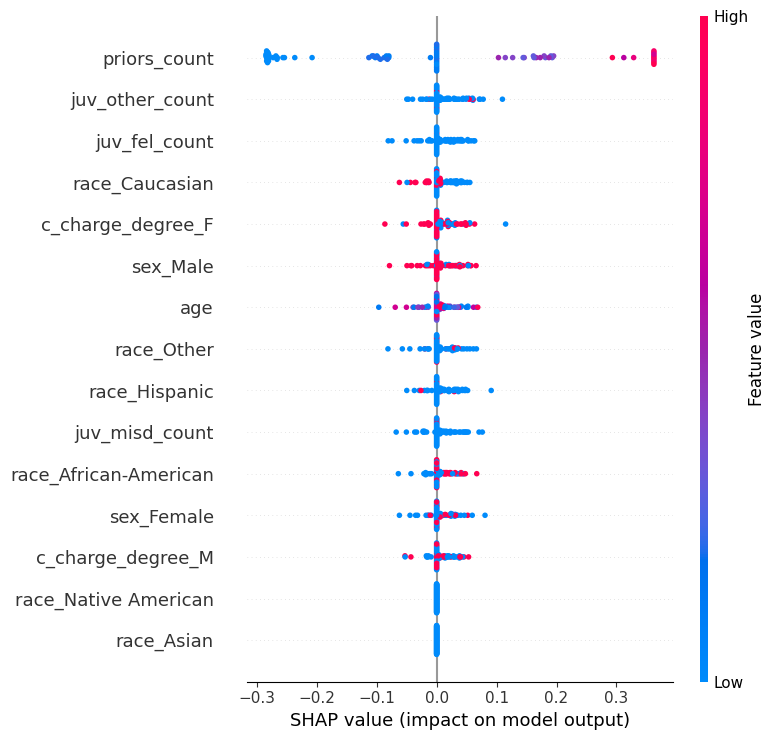

In [54]:
# ============================
# Paso 11: Summary plot de SHAP
# ============================

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_explain_encoded,
    feature_names=X_explain_encoded.columns,
    show=True
)

In [55]:
# ============================
# Paso 11.1: Importancia promedio absoluta por variable SHAP
# ============================

shap_importance = pd.DataFrame({
    "feature": X_explain_encoded.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance

,feature,mean_abs_shap
1,priors_count,0.172810
4,juv_other_count,0.019934
2,juv_fel_count,0.019191
7,race_Caucasian,0.018283
13,c_charge_degree_F,0.017996
12,sex_Male,0.017332
0,age,0.017190
10,race_Other,0.015849
8,race_Hispanic,0.015224
3,juv_misd_count,0.014689


In [56]:
# ============================
# Paso 11.2: Agrupar importancia conceptual
# ============================

def conceptual_feature_name(feature):
    if feature.startswith("race_"):
        return "race"
    if feature.startswith("sex_"):
        return "sex"
    if feature.startswith("c_charge_degree_"):
        return "c_charge_degree"
    return feature

shap_importance_grouped = (
    shap_importance
    .assign(conceptual_feature=shap_importance["feature"].apply(conceptual_feature_name))
    .groupby("conceptual_feature", as_index=False)["mean_abs_shap"]
    .sum()
    .sort_values("mean_abs_shap", ascending=False)
)

shap_importance_grouped

,conceptual_feature,mean_abs_shap
5,priors_count,0.172810
6,race,0.063861
7,sex,0.031288
1,c_charge_degree,0.031087
4,juv_other_count,0.019934
2,juv_fel_count,0.019191
0,age,0.017190
3,juv_misd_count,0.014689


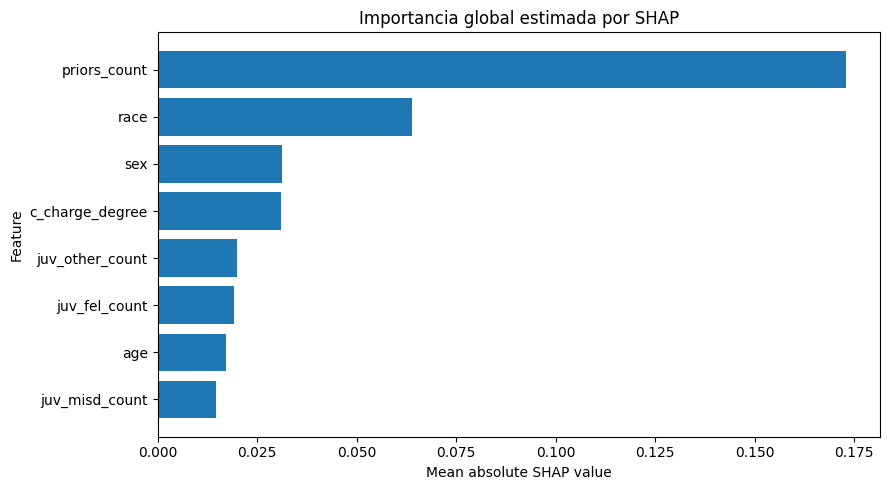

In [57]:
# ============================
# Paso 11.3: Gráfica profesional de importancia agrupada
# ============================

plt.figure(figsize=(9, 5))

plt.barh(
    shap_importance_grouped["conceptual_feature"][::-1],
    shap_importance_grouped["mean_abs_shap"][::-1]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Importancia global estimada por SHAP")
plt.tight_layout()
plt.show()

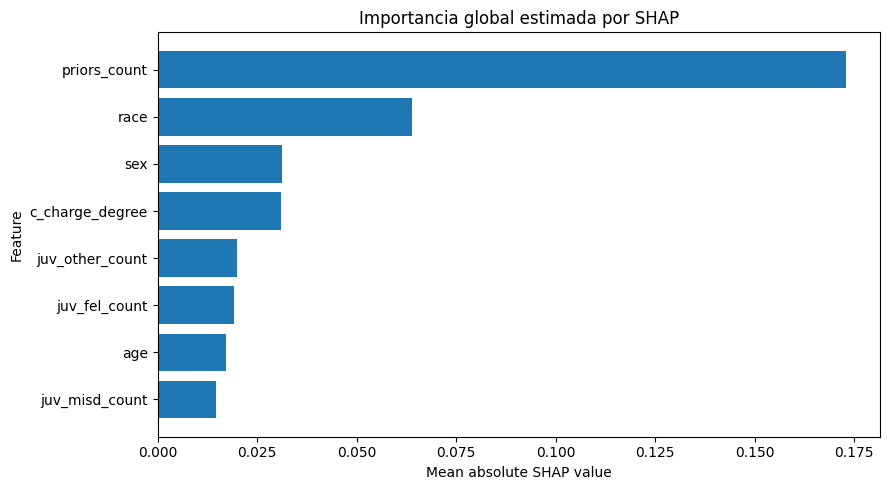

In [58]:
# Guardar gráfica de importancia agrupada

plt.figure(figsize=(9, 5))

plt.barh(
    shap_importance_grouped["conceptual_feature"][::-1],
    shap_importance_grouped["mean_abs_shap"][::-1]
)

plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.title("Importancia global estimada por SHAP")
plt.tight_layout()

plt.savefig("shap_importancia_agrupada.png", dpi=300, bbox_inches="tight")
plt.show()